# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# importing MyDrive for next piece of code
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Understanding the structure of the data

In [ ]:
# read the data
df = pd.read_csv('/content/drive/MyDrive/MIT/Project Assessment: Foundations of AI/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Return the number of rows and columns
df.shape

(1898, 9)

#### Observations:
The total number of rows is 1898 across 9 total columns.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# check what datatypes each column is set to
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The order_id, customer_id, food_preperation_time, and delivery_time columns are all type int64

The resturant_name, cuisine_type, day_of_the_week, and rating columns are all type: object

The cost_of_the_order column is type: float64

(columns) by dtype:
dtypes: float64(1), int64(4), object(4)

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# check and return the total number of null values in each column
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
There are no missing or null values within the dataset.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# return the statistical analaysis of all numerical columns in the data set
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:
Food preperation time:

Minimum: 20.0 minutes

Mean (AVG): 27.37 minutes

Maximum: 35.0 minutes

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# count the total number of each value within the rating column
Total = df['rating'].value_counts()
Percentage = df['rating'].value_counts(normalize=True)

print(Total)
print("-" * 50)
print(round(Percentage*100, 2))

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64
--------------------------------------------------
rating
Not given    38.78
5            30.98
4            20.34
3             9.91
Name: proportion, dtype: float64


#### Observations:
The total number of orders without a rating is 736
or 38.78% of the 1898 orders in the data set

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]


--- Distribution of order_id ---
Number of unique order_id: 1898
Most frequent order_id:
order_id
1478056    1
1477147    1
1477685    1
1477070    1
1477334    1
Name: count, dtype: int64

--- Distribution of customer_id ---
Number of unique customer_id: 1200
Most frequent customer_id:
customer_id
52832     13
47440     10
83287      9
250494     8
259341     7
Name: count, dtype: int64

--- Distribution of restaurant_name ---


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


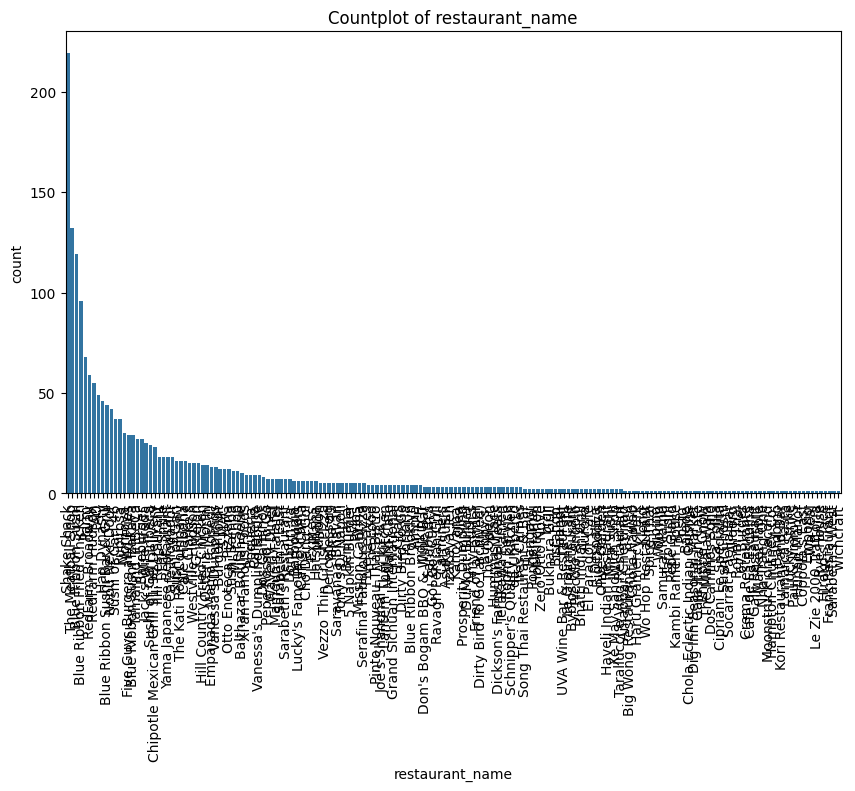


--- Distribution of cuisine_type ---


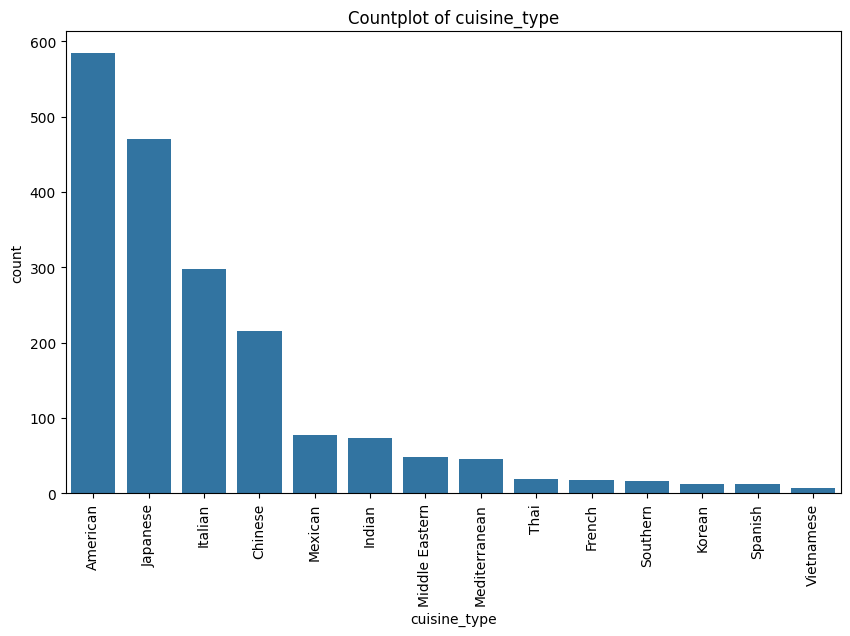


--- Distribution of cost_of_the_order ---


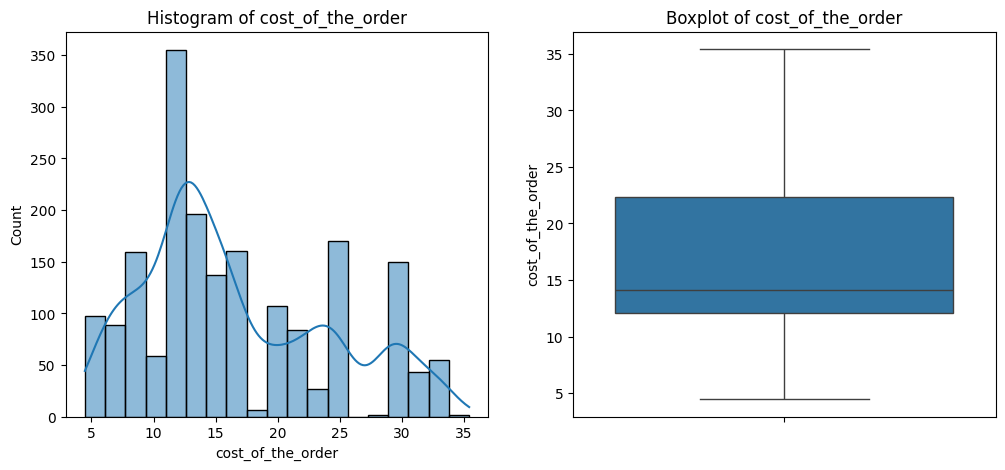


--- Distribution of day_of_the_week ---


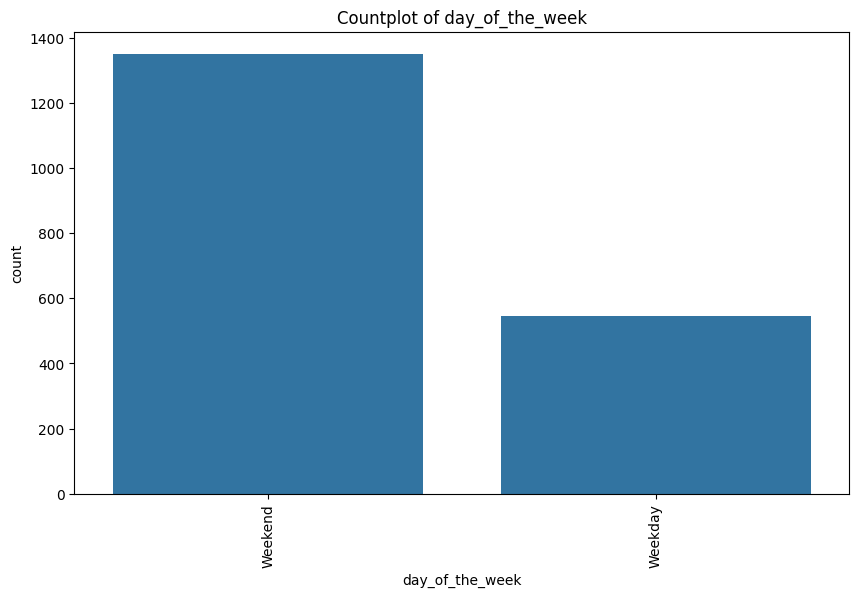


--- Distribution of rating ---


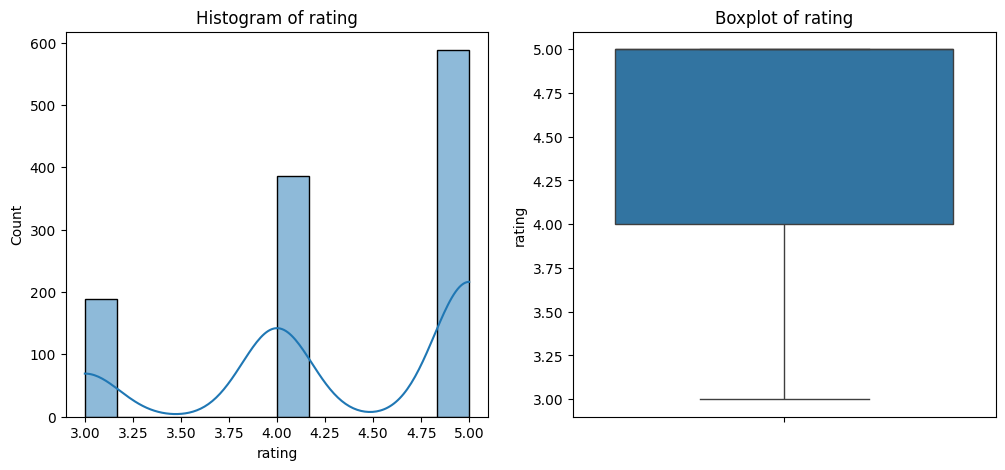


--- Distribution of food_preparation_time ---


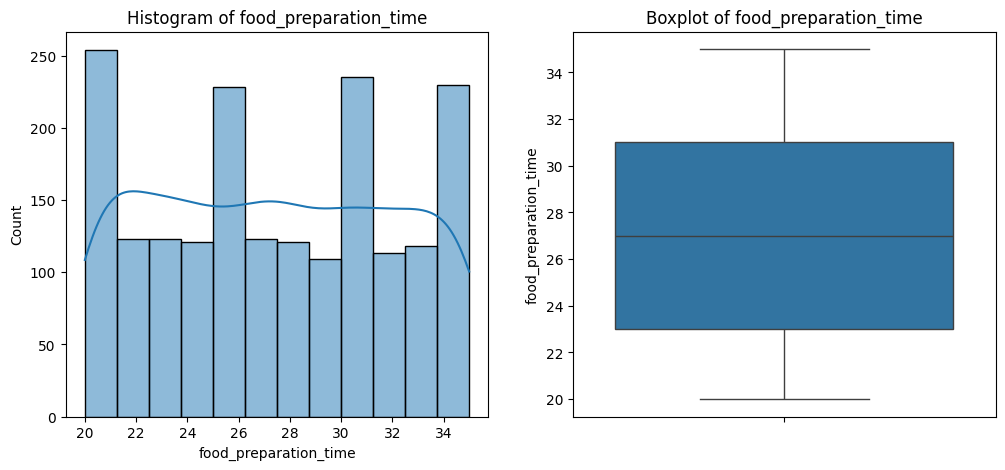


--- Distribution of delivery_time ---


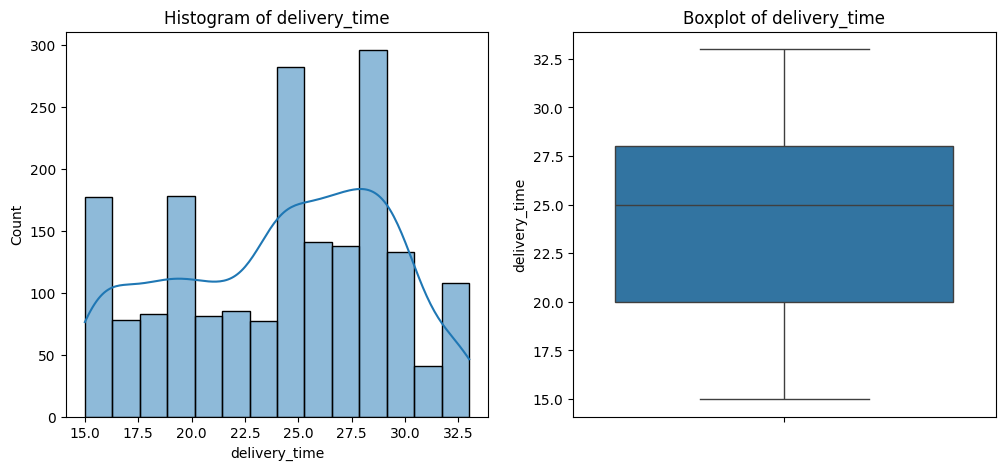


--- Distribution of Total_Time ---


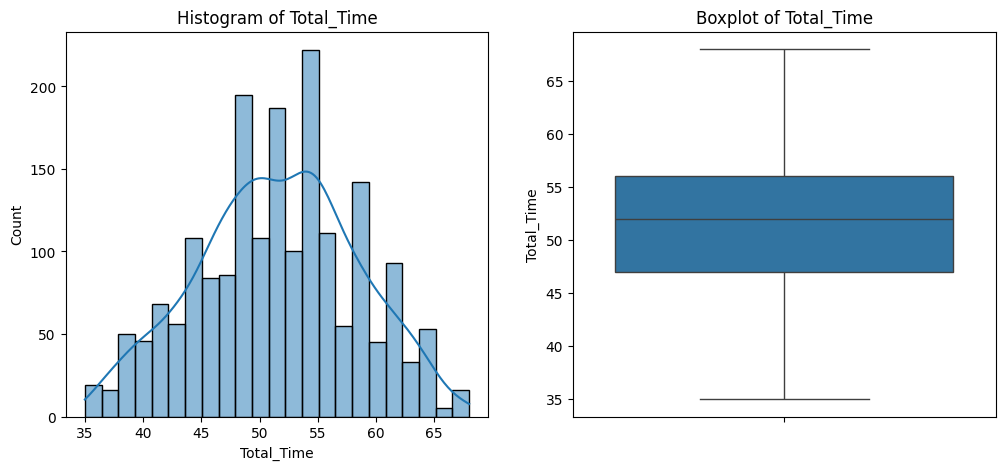

In [ ]:
# Function to plot numerical distributions
def plot_numerical_distribution(df, column):
    print(f"\n--- Distribution of {column} ---")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

# Function to plot categorical distributions
def plot_categorical_distribution(df, column):
    print(f"\n--- Distribution of {column} ---")
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(f'Countplot of {column}')
    plt.show()


# Iterate through each column and plot its distribution
for column in df.columns:
    if df[column].dtype in ['int64', 'float64'] and column not in ['order_id', 'customer_id']:
        plot_numerical_distribution(df, column)
    elif df[column].dtype == 'object':
        plot_categorical_distribution(df, column)
    elif column in ['order_id', 'customer_id']:
        print(f"\n--- Distribution of {column} ---")
        print(f"Number of unique {column}: {df[column].nunique()}")
        print(f"Most frequent {column}:\n{df[column].value_counts().head(5)}")

#### Observations:
**order_id and customer_id:** These are unique identifiers. order_id is unique for each row, as expected. customer_id shows that some customers place multiple orders, with the most frequent customer placing 13 orders.

**restaurant_name**: This is a categorical variable with many unique values. The distribution shows a long tail, meaning a few restaurants receive a significantly higher number of orders compared to the majority.

**cuisine_type**: This is also a categorical variable. American cuisine appears to be the most frequent, followed by Japanese and Italian. There's a varied distribution across different cuisine types.

**cost_of_the_order**: This numerical variable appears to have a right-skewed distribution, with most orders costing between \$10 and \$20. There are some orders with higher costs, and a minimum around $4.47.

**day_of_the_week**: This categorical variable indicates a higher number of orders placed on Weekend compared to Weekday.

**rating**: Initially an object type, it contains Not given values. After conversion to numeric, it's clear that a substantial portion of orders (around 38.78%) do not have a rating. Among the rated orders, 5 is the most frequent rating, followed by 4 and 3. There are no ratings below 3 in the dataset.

**food_preparation_time**: This numerical variable shows a fairly uniform or slightly bimodal distribution, ranging from 20 to 35 minutes. Most orders fall within this relatively narrow range, indicating consistent preparation times.

**delivery_time**: Similar to food_preparation_time, this numerical variable has a relatively narrow range, from 15 to 33 minutes, with a distribution centered around 25 minutes. It appears fairly symmetric.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# to check if there are any duplicate orders in the table
print(df['order_id'].duplicated().sum())

# return a table of the top 5 resturants by value count, ensuring there are no duplicate orders
df.value_counts('restaurant_name').head()

0


,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The top 5 resturants by order volume are, in order:

Shake Shack

The Meatball Shop

Blue Ribbon Sushi

Blue Ribbon Fried Chicken

Parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# filter the DataFrame where the day_of_the_week is a weekend
weekend_orders = df[df['day_of_the_week'] == 'Weekend']

# return the top output from counting all values in cuisine_type where the weekend_orders condition is met
most_popular_cuisine_weekend = weekend_orders['cuisine_type'].value_counts().head(1)
display(most_popular_cuisine_weekend)

,count
cuisine_type,
American,415


#### Observations:
The most popular cuisine on weekends is American, with 415 results.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# count the total number of orders over 20
orders_over_20 = len(df[df['cost_of_the_order'] > 20])
print(orders_over_20)

# return the percentage of orders_over_20 compared to all orders placed
orders_over_20_percent = orders_over_20 / len(df) * 100
print(orders_over_20_percent)

555
29.24130663856691


#### Observations:
There are 555 total orders above $20 out of the 1898 total orders in the DataFrame, which is 29.24% of the total orders.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# return the satistical summary for the delivery_time column
df['delivery_time'].describe()

,delivery_time
count,1898.000000
mean,24.161749
std,4.972637
min,15.000000
25%,20.000000
50%,25.000000
75%,28.000000
max,33.000000


#### Observations:
The mean, or average, delivery time is roughly 24 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# return the top 3 customer_id's by their total count
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
Customers 52832, 47440, and 83287 have placed the most orders and thus would recieve the 20% discount.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


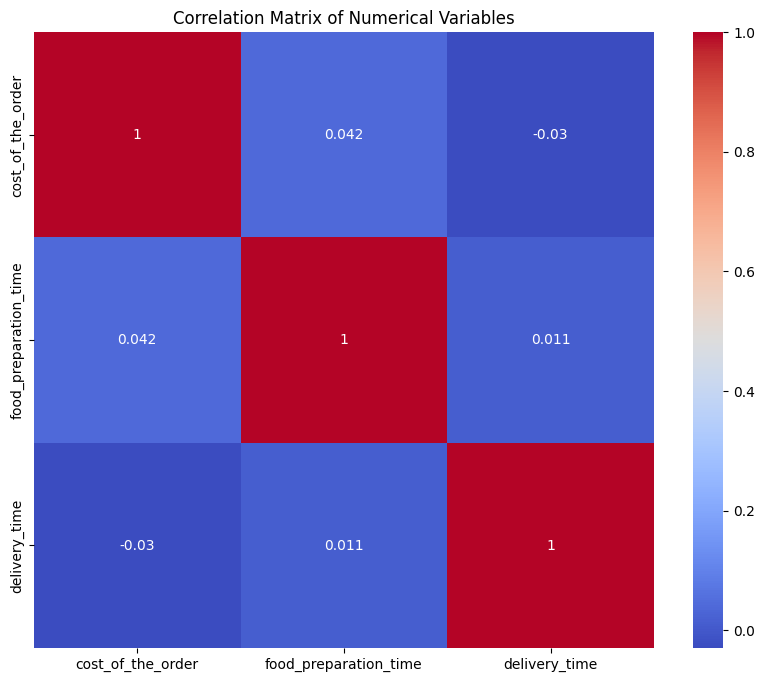

In [ ]:
# visualize the correlation between the numerical variables in the dataset to identify any strong relationships.
plt.figure(figsize=(10, 8))
sns.heatmap(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

#### Observations:
The heat map of the numerical values shows us that there is almost no correlation between the cost of the order and the time for each step within the delivery process. This highlights that the cost of the order doesn't mean slower or faster prep / delivery times.

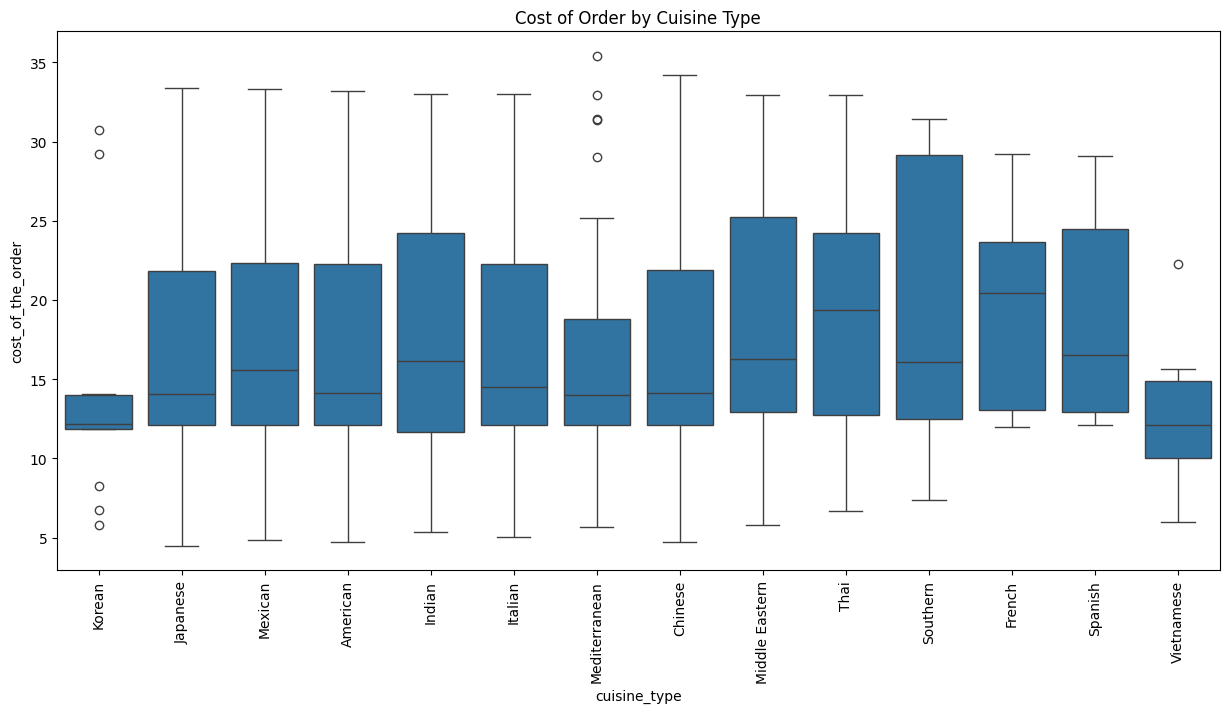

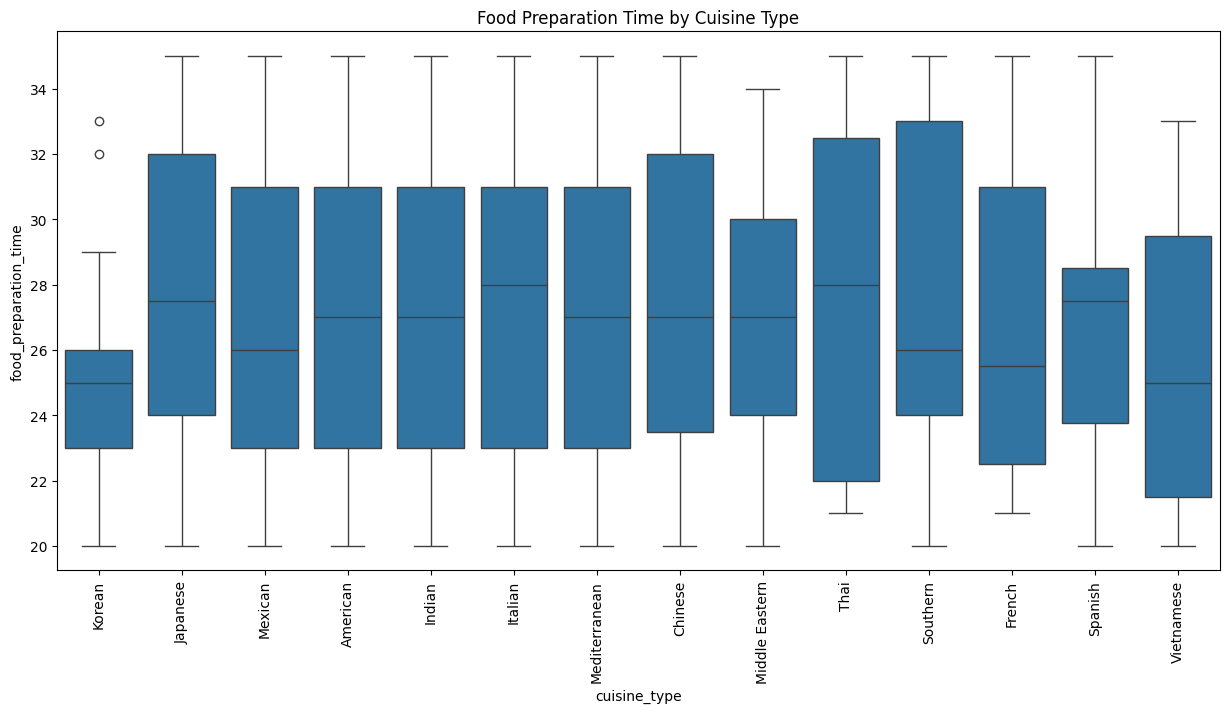

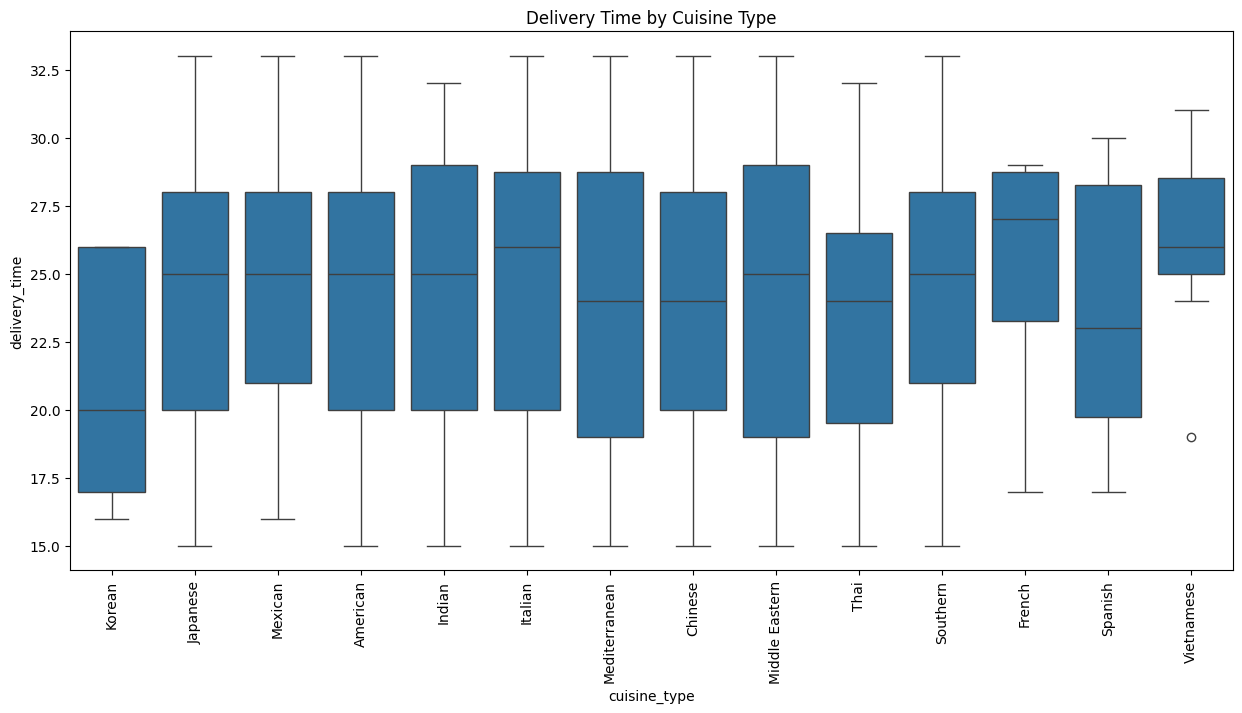

In [ ]:
# visualize how cost_of_the_order, food_preparation_time, delivery_time, and Total_Time vary across different cuisine_type
plt.figure(figsize=(15, 7))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.xticks(rotation=90)
plt.title('Cost of Order by Cuisine Type')
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df)
plt.xticks(rotation=90)
plt.title('Food Preparation Time by Cuisine Type')
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(x='cuisine_type', y='delivery_time', data=df)
plt.xticks(rotation=90)
plt.title('Delivery Time by Cuisine Type')
plt.show()

#### Observations:
**Cost by cusine:**

The 25th percentile of all but Vietnamese food is roughly $12.50.
Korean and Vietnamese cuisine food have a much lower maximum cost than the others, along witrh a much tighter IQR, meaning their order costs are generally lower and do not vary as much as the other types.

**Prep time by cusine:**

All cusines have an average, or 50th percentile, food prep time of about 25 to 27 minutes.With the qucikest orders taking 20 to 21 minutes and the slowest taking more than 33 minutes (with the exception of Korean, which is about 29 minutes excluding the 2 outliers)

**Delivery time by cusine:**
Delivery time is heavily influenced by the distance the customer is away from the resturant leading to large variations in the min and max delivery times of most of the cusine types. It is hard to draw conclusions from this comparison due to this.

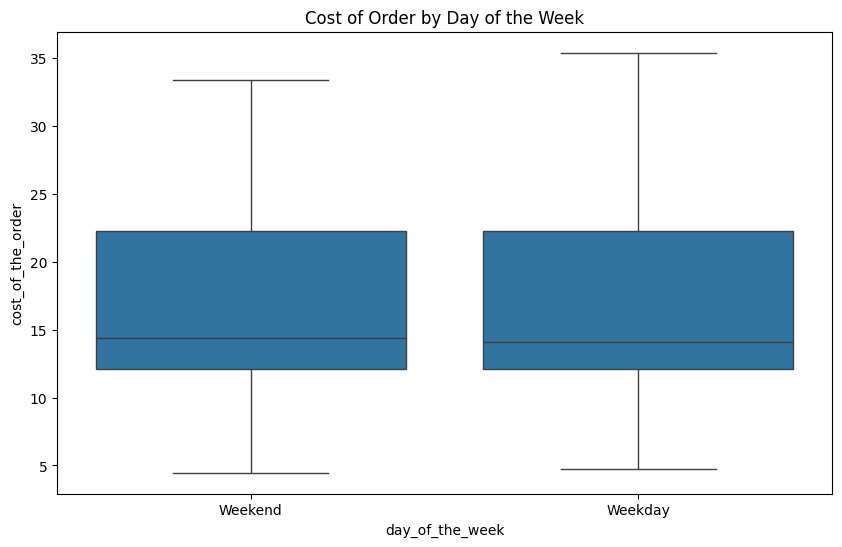

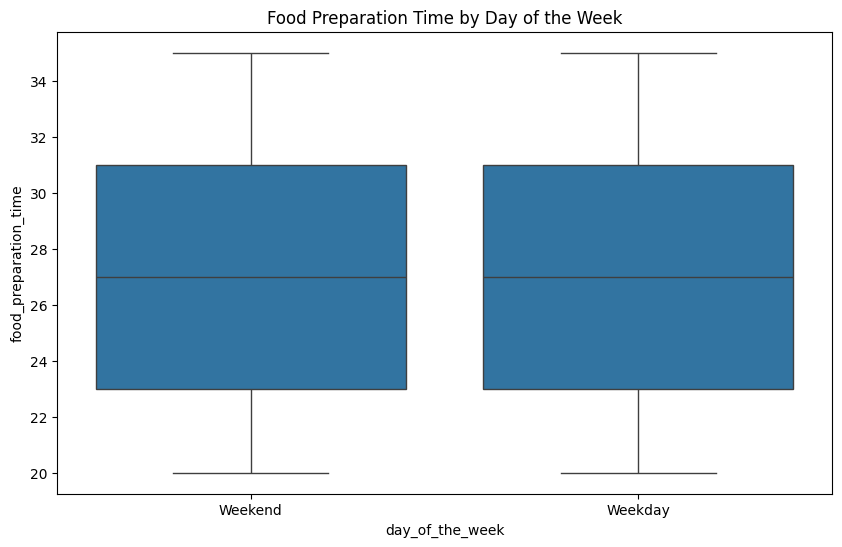

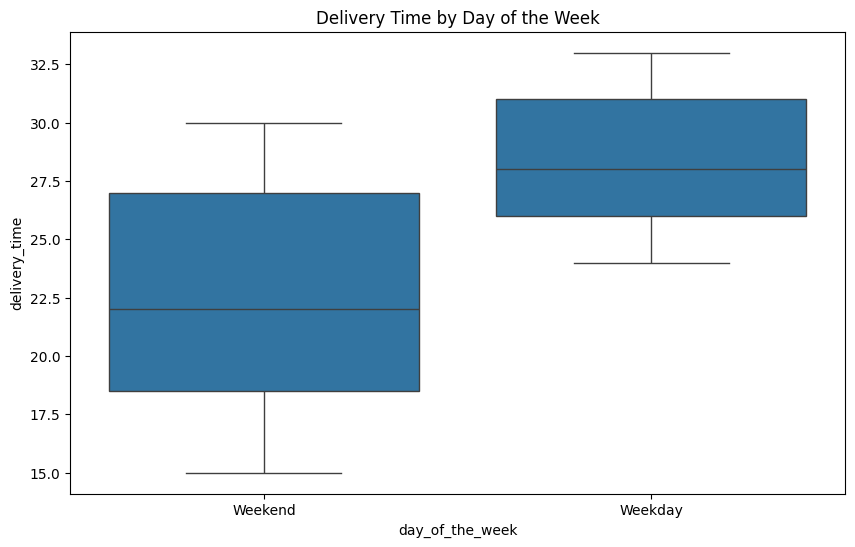

In [ ]:
# visualize how cost_of_the_order, food_preparation_time, delivery_time, and Total_Time vary across different day_of_the_week
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_the_week', y='cost_of_the_order', data=df)
plt.title('Cost of Order by Day of the Week')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_the_week', y='food_preparation_time', data=df)
plt.title('Food Preparation Time by Day of the Week')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Delivery Time by Day of the Week')
plt.show()

#### Observations:
**Cost & Prep time by day of the week:**

We see no variation between the day of the week the order was placed and the cost of the order becasue the prices do not change based off of the day of the week.

The same is true for the preparation time of the order, the day of the week does not dictate how long an order takes to make.

**Delivery time by day of the week:**

Here we see a much higher mean delivery time during the weekdays, this could be due to several outside factors including more traffic during the weekdays. The same can be said about the minimums since it takes roughly 10 more minutes to deliver an order on weekdays.

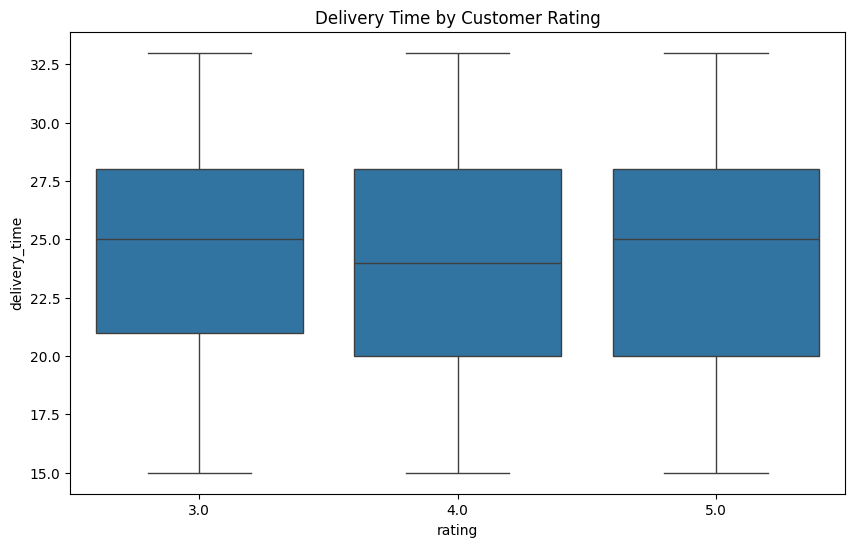

In [ ]:
# visualize how cost_of_the_order, food_preparation_time, delivery_time, and Total_Time vary across different rating.
# Remove 'Not given' from ratings for better visualization if it's still present as object (it was converted to numeric earlier but good to check)

plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='delivery_time', data=df)
plt.title('Delivery Time by Customer Rating')
plt.show()

#### Observations:
Based on the graph, we can see there is very little variance in the rating a customer gives when dleivery time changes, this reinforces the information from the heat map which slowed very little correlation between these values.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# convert rating to numeric, coercing 'Not given' to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# group by restaurant and calculate rating count and average rating
restaurant_ratings = df.groupby('restaurant_name')['rating'].agg(rating_count='count', average_rating='mean').reset_index()

# filter for restaurants with rating count > 50 and average rating > 4
promotional_restaurants = restaurant_ratings[(restaurant_ratings['rating_count'] > 50) & (restaurant_ratings['average_rating'] > 4)]

display(promotional_restaurants)

,restaurant_name,rating_count,average_rating
20,Blue Ribbon Fried Chicken,64,4.328125
21,Blue Ribbon Sushi,73,4.219178
136,Shake Shack,133,4.278195
153,The Meatball Shop,84,4.511905


#### Observations:
The resturants getting the promotional offer are:

Blue Ribbon Fried Chicken

Blue Ribbon Sushi

Shake Shack

The Meatball Shop

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# filters DataFrame for where orders are greater than $20
orders_over_20 = df[df['cost_of_the_order'] > 20]

# filters the output from orders_over_20 by the cost_of_the_order, multiples by the 25% charged, and sums all values
over_20_revenue = (orders_over_20['cost_of_the_order'] * 0.25).sum()
print(f"Total revenue of orders over $20: ${over_20_revenue}")

# filters DataFrame for where orders are between $5 and $20
orders_over_5 = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]

# filters the output from orders_over_5 by the cost_of_the_order, multiples by the 15% charged, and sums all values
over_5_revenue = (orders_over_5['cost_of_the_order'] * 0.15).sum()
print(f"Total revenue of orders over $5: ${over_5_revenue}")

#combines the 2 variables to return the total revenue gained by this policy
total_revenue = over_20_revenue + over_5_revenue
print(f"Total revenue of orders: ${total_revenue}")

Total revenue of orders over $20: $3688.7275
Total revenue of orders over $5: $2477.5755
Total revenue of orders: $6166.303


#### Observations:
The total revenue generated by the company is $6,166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# problem states food_preparation_time is the time take from order placed to driver pickup & delivery_time is time taken from pickup to delivery
# we want to know total time from order placed to delivery, so we need to add the Toal_Time column which displays the sum of food_preparation_time and delivery_time
df['Total_Time'] = df['delivery_time'] + df['food_preparation_time']

# calculates the number of orders with a Total_Time greater than 60
time_taken = len(df[df['Total_Time'] > 60])
print(time_taken)

# calculates the percentage of orders that take more than 1 hour to deliver
time_taken_percentage = time_taken / len(df) * 100
print(time_taken_percentage)

200
10.537407797681771


#### Observations:
There are 200 total orders above 1 hour total time out of the 1898 total orders in the DataFrame, which is 10.53% of the total orders.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# displays the mean delivery time by the day_of_the_week column
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
The average delivery time during a weekday is roughly 6 minutes slower (28 minutes vs 22 on weekends)

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

#### Conclusions:

**Data Quality:** The dataset is clean with no missing values, and order IDs are unique, ensuring reliable analysis.

**Top Performers:** Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm are the top 5 restaurants by order volume.

**Cuisine Popularity:** American cuisine is notably the most popular on weekends.

**Order Value Distribution:** Approximately 29.24% of orders cost more than $20, contributing significantly to revenue.

**Customer Feedback Gap:** A substantial portion (38.78%) of orders do not receive a rating, indicating a potential missed opportunity for feedback collection.

**Delivery Efficiency:** The mean delivery time is around 24 minutes. However, weekday deliveries are significantly slower (mean of ~28 minutes) compared to weekends (mean of ~22 minutes).

**Extended Delivery Times:** 10.53% of all orders exceed a total delivery time of 60 minutes.

**Promotional Eligibility:** Four of the top five restaurants (Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, The Meatball Shop) meet the criteria for promotional offers, highlighting their consistent performance and high customer satisfaction.

**Revenue Generation:** The company generates a total net revenue of $6166.30 from the current commission structure.

**Correlation Insights:** There is a very low correlation between the cost of an order and its preparation/delivery times, and customer ratings show little variance with delivery times.

### Recommendations:
**Leverage Top Restaurants:** Continue to partner closely with and promote the top-performing restaurants (Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, Parm). Since 4 of these qualify for promotional offers, actively promoting them can drive increased order volume and revenue, capitalizing on their proven popularity and high ratings.

**Improve Weekday Delivery:** Investigate the factors contributing to slower delivery times during weekdays. This could involve optimizing delivery routes, increasing driver availability during peak weekday hours, or implementing dynamic pricing for delivery to balance demand and supply.

**Boost Customer Ratings:** Implement strategies to encourage more customers to provide ratings. This could include in-app prompts, post-delivery notifications, or small incentives for completing a rating. More ratings will provide richer feedback for restaurant and service improvement.

**Address Long Delivery Times:** Analyze the 10.53% of orders that take over 60 minutes to understand the root causes (e.g., specific restaurants, cuisine types, delivery zones). Take corrective actions such as working with restaurants to improve preparation efficiency or adjusting estimated delivery times to manage customer expectations.

**Targeted Marketing for Cuisine:** Capitalize on the popularity of American cuisine, especially on weekends, through targeted marketing campaigns. Consider recruiting more highly-rated American restaurants to expand offerings and meet demand.

**Operational Optimization:** While food preparation time is generally consistent, focus on the handover process from restaurant to delivery person and overall delivery logistics to ensure seamless and efficient service, especially given the identified difference in weekday vs. weekend delivery times.

In [10]:
import scipy.stats
from scipy.stats import norm

mean = 55000
std_dev = 6200

# Calculate the cumulative probability for salaries less than $67,000
prob_less_than_67000 = norm.cdf(67000, mean, std_dev)

# Calculate the cumulative probability for salaries less than $59,000
prob_less_than_59000 = norm.cdf(59000, mean, std_dev)

# The percentage of employees earning between $59,000 and $67,000
percentage = (prob_less_than_67000 - prob_less_than_59000)

print(f"The percentage of employees earning between $59,000 and $67,000 is approximately {percentage:.2f}%")

The percentage of employees earning between $59,000 and $67,000 is approximately 0.23%


---